# Proyek Klasifikasi Gambar: Fashion Apparel Image Classification Dataset
- **Nama:** Achmad Firza Fuadi
- **Email:** firzaachmad31@gmail.com
- **ID Dicoding:** firzafuad

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Library untuk manipulasi file dan direktori serta analisis data
import os
import shutil
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Library untuk manipulasi gambar dan augmentasi
from PIL import Image
from tensorflow.image import random_brightness, random_crop, random_contrast, random_flip_left_right, resize_with_crop_or_pad
from tensorflow.keras.layers import RandomRotation

In [3]:
# Library untuk modeling dan evaluasi deep learning
import pathlib
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Adamax, Nadam, Adagrad, Adadelta
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, Activation, TFSMLayer
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Preparation

### Data Loading

In [5]:
path = kagglehub.dataset_download("shreyanshverma27/new-data-fashion")
path = os.path.join(path, "Apparel images dataset new")
dataset_dir = 'dataset/'

# hapus direktori jika sudah ada untuk menghindari error
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir, ignore_errors=True)

Using Colab cache for faster access to the 'new-data-fashion' dataset.


In [6]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(dataset_dir, exist_ok=True)
categories = os.listdir(path)

# Salin file dan folder dari train, test, dan validation ke direktori gabungan
for category in categories:
    color, label = category.split("_")
    category_dir = os.path.join(path, category)

    if os.path.isdir(category_dir) :
        for img in os.listdir(category_dir):
            img_path = os.path.join(category_dir, img)
            if os.path.isfile(img_path):
                # Buat direktori kategori di dataset_dir jika belum ada
                os.makedirs(os.path.join(dataset_dir, label), exist_ok=True)
                # Salin file gambar ke direktori kategori di dataset_dir
                shutil.copy(img_path, os.path.join(dataset_dir, label, img.split(".")[0]+"_"+color+".jpg"))

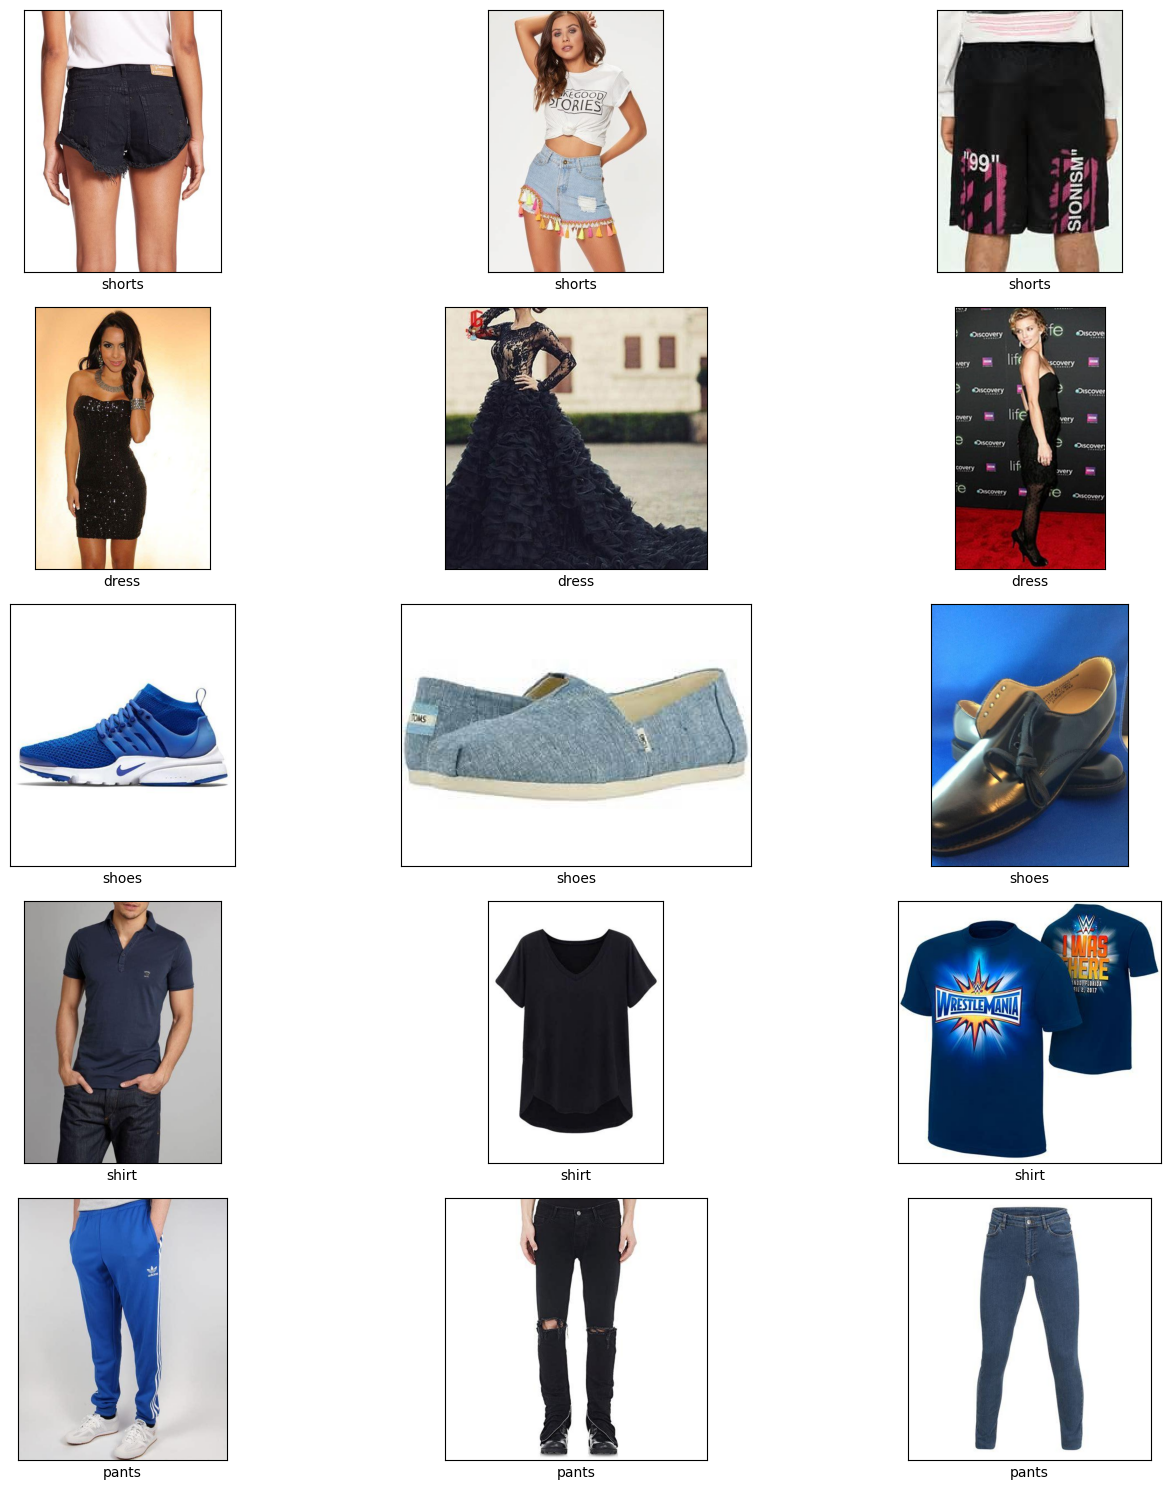

In [7]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
prod_images = {}

for i in os.listdir(dataset_dir):
    prod_images[i] = os.listdir(os.path.join(dataset_dir, i))

# Menampilkan secara acak 3 gambar di bawah setiap dari masing-masing kelas dari data.

# Menampilkan secara acak 3 gambar di bawah setiap kelas dari dataset
fig, axs = plt.subplots(len(prod_images.keys()), 3, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(dataset_dir)):
    images = np.random.choice(prod_images[class_name], 3, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(dataset_dir, class_name, image_name)
        img = Image.open(img_path)  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

### Data Preprocessing

#### Split Dataset

In [8]:
def collect_data(directory):
    data = []
    labels = []

    for category in os.listdir(directory):
        category_dir = os.path.join(directory, category)
        category = category.replace('_augmented', '')

        if os.path.isdir(category_dir):
            for img_name in os.listdir(category_dir):
                img_path = os.path.join(category_dir, img_name)
                data.append(img_path)
                labels.append(category)

    return np.array(data), np.array(labels)

In [9]:
# Kumpulkan semua path gambar dan labelnya ke dalam list
X, y = collect_data(dataset_dir)

In [10]:
# Split data menjadi train, test, dan validation
X_train, X_testval, y_train, y_testval = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_testval, y_testval, test_size=0.5, random_state=42)

df_train = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_test = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})
df_val = pd.DataFrame({'path':X_val,'labels':y_val,'set':'validation'})
df_train.head()

,path,labels,set
0,dataset/dress/06677e9166ce249cbe6f7cbf6ea4fae6...,dress,train
1,dataset/shirt/df29b6a339eb634139cffdab6d963390...,shirt,train
2,dataset/dress/c749c9d74fce51d4eff6aab2eea6ad34...,dress,train
3,dataset/shoes/a342aae68e0fb258f05443da03a8ba9b...,shoes,train
4,dataset/shoes/e1000fb82c4b88084463f7358c014fc4...,shoes,train


In [11]:
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')

categories = os.listdir(dataset_dir)
# Buat direktori baru untuk dataset gabungan
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Salin data yang sudah di split ke dalam folder train, test, dan validation
for category in categories :
    category_dir = os.path.join(train_dir, category)
    shutil.rmtree(category_dir, ignore_errors=True)
    os.makedirs(category_dir, exist_ok=True)
    for src in df_train[df_train['labels'] == category]['path']:
        dst = os.path.join(category_dir, os.path.basename(src))
        if os.path.isdir(category_dir):
            shutil.copyfile(src, dst, follow_symlinks=True)

    category_dir = os.path.join(test_dir, category)
    os.makedirs(category_dir, exist_ok=True)
    for src in df_test[df_test['labels'] == category]['path']:
        dst = os.path.join(category_dir, os.path.basename(src))
        if os.path.isdir(category_dir):
            shutil.copyfile(src, dst, follow_symlinks=True)

    category_dir = os.path.join(val_dir, category)
    os.makedirs(category_dir, exist_ok=True)
    for src in df_val[df_val['labels'] == category]['path']:
        dst = os.path.join(category_dir, os.path.basename(src))
        if os.path.isdir(category_dir):
            shutil.copyfile(src, dst, follow_symlinks=True)

#### Data Augmentation

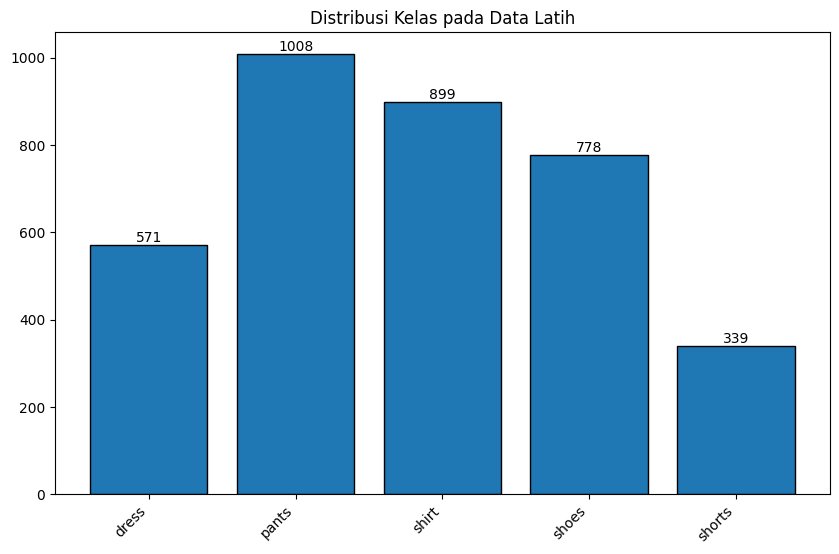

In [12]:
# Visualisasi distribusi kelas pada data latih
labels, counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(labels)), counts, edgecolor='black')

# put the label under each bar
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')

# optional: put the count above each bar
for c, b in zip(counts, bars):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        str(c),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Kelas pada Data Latih')
plt.show()

In [13]:
# definisikan fungsi augmentasi gambar

def brightness(image):
    return random_brightness(image, max_delta=0.1)
def contrast(image):
    return random_contrast(image, 0.9, 1.1)
def crop(image):
    return random_crop(resize_with_crop_or_pad(image, 224+10, 224+10), [224, 224, 3])
def flip_left_right(image):
    return random_flip_left_right(image)
def rotate(image):
    rotator = RandomRotation(float(tf.random.uniform([], -1, 1)))
    return rotator(image)

In [14]:
nb_augmented = 400
transformations = {
    'brightness': brightness,
    'contrast': contrast,
    'flip_left_right': flip_left_right,
    'crop': crop,
    'rotate': rotate
}


cat_to_augment = ['dress', 'shorts']

for category in cat_to_augment:
    images = df_train[df_train['labels'] == category]['path'].to_list()
    for i in range(nb_augmented):
        image_chosen = random.choice(images) # Secara acak memilih gambar dari kelas tersebut
        img = tf.io.read_file(image_chosen)
        img = tf.image.decode_jpeg(img, channels=3)

        count = random.randint(1, len(transformations))
        transform_keys = random.sample(list(transformations), count) # Secara acak memilih dan memanggil metode
        for key in transform_keys:
            img = transformations[key](img) # Terapkan transformasi pada gambar

        save_dir = os.path.join(train_dir, category+'_augmented')
        os.makedirs(save_dir, exist_ok=True)

        save_path = os.path.join(save_dir, f'augmented_{i}_{os.path.basename(image_chosen)}')
        encoded_image = tf.io.encode_jpeg(tf.cast(img, tf.uint8))
        tf.io.write_file(save_path, encoded_image)

In [15]:
X_train, y_train = collect_data(train_dir)
df_train = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_train.head()

,path,labels,set
0,dataset/train/dress_augmented/augmented_288_c5...,dress,train
1,dataset/train/dress_augmented/augmented_126_ef...,dress,train
2,dataset/train/dress_augmented/augmented_364_e7...,dress,train
3,dataset/train/dress_augmented/augmented_161_b7...,dress,train
4,dataset/train/dress_augmented/augmented_272_f7...,dress,train


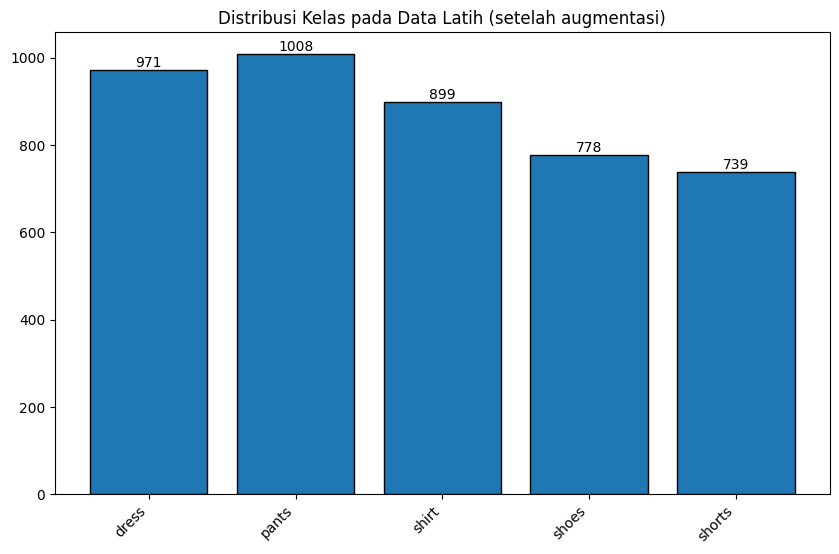

In [16]:
# Visualisasi distribusi kelas pada data latih
labels, counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(labels)), counts, edgecolor='black')

# put the label under each bar
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')

# optional: put the count above each bar
for c, b in zip(counts, bars):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        str(c),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Kelas pada Data Latih (setelah augmentasi)')
plt.show()

In [17]:
# Gabungkan DataFrame df_train, df_test dan df_val
df_all = pd.concat([df_train, df_test, df_val], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))


# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset_Final/"
shutil.rmtree(dataset_path, ignore_errors=True)


set         labels
test        dress      184
            pants      322
            shirt      285
            shoes      250
            shorts     158
train       dress      971
            pants     1008
            shirt      899
            shoes      778
            shorts     739
validation  dress      197
            pants      339
            shirt      272
            shoes      261
            shorts     130
dtype: int64 


                                                   path labels    set
3904  dataset/train/pants/4dab4741e7c59e198833fee416...  pants  train
2181  dataset/train/shirt/09bd8409009f372cc74c4d32f9...  shirt  train
5074  dataset/shoes/62bb0cbad3a70050e04322e5f4d610a9...  shoes   test
1853  dataset/train/shoes/08bbfde61bf2922ae0a00219e0...  shoes  train
926   dataset/train/dress/fe453d2f1e0c747b5949ff583d...  dress  train


In [18]:
for row in df_all.itertuples(index=False):
    file_path = row[0]

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row[2],row[1])) == False:
        os.makedirs(os.path.join(dataset_path,row[2],row[1]))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row[2],row[1],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

## Modelling

In [19]:
TRAIN_DIR = "Dataset_Final/train/"
TEST_DIR = "Dataset_Final/test/"
VAL_DIR = "Dataset_Final/validation/"

# Buat objek ImageDataGenerator yang menormalkan gambar
train_datagen = ImageDataGenerator(rescale=1/255.,
                                   rotation_range=20,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   zoom_range=0.1,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(224,224),
                                              color_mode='rgb',
                                              class_mode='categorical',
                                              shuffle=True)

validation_generator = val_datagen.flow_from_directory(VAL_DIR,
                                                   batch_size=32,
                                                   target_size=(224,224),
                                                   color_mode='rgb',
                                                   class_mode='categorical',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(224,224),
                                                  color_mode='rgb',
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 4395 images belonging to 5 classes.
Found 1199 images belonging to 5 classes.
Found 1199 images belonging to 5 classes.


In [31]:
# tf.keras.backend.clear_session()
model = Sequential()

model.add(InputLayer(input_shape=(224, 224, 3)))


model.add(Conv2D(64, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))


model.add(Conv2D(128, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())


model.add(Dense(256, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(len(train_generator.class_indices), activation='softmax'))

######################### Compile Model ################################
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the Model Architecture
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   102,760,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,838,981 (392.30 MB)

 Trainable params: 102,838,085 (392.30 MB)

 Non-trainable params: 896 (3.50 KB)

None


In [32]:
class Callback95(Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.95):
      print("\nAkurasi telah mencapai >95%!")
      self.model.stop_training = True
callbacks = Callback95()

In [33]:
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [34]:
# Melatih model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[callbacks]
)

Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 58s 389ms/step - accuracy: 0.5327 - loss: 1.4156 - val_accuracy: 0.2636 - val_loss: 1.6491
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 371ms/step - accuracy: 0.6947 - loss: 0.8613 - val_accuracy: 0.3845 - val_loss: 1.3191
Epoch 3/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 371ms/step - accuracy: 0.7414 - loss: 0.7288 - val_accuracy: 0.6022 - val_loss: 0.9094
Epoch 4/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 368ms/step - accuracy: 0.7731 - loss: 0.6497 - val_accuracy: 0.8057 - val_loss: 0.5406
Epoch 5/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 368ms/step - accuracy: 0.7710 - loss: 0.6194 - val_accuracy: 0.6764 - val_loss: 0.8363
Epoch 6/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 369ms/step - accuracy: 0.7967 - loss: 0.5923 - val_accuracy: 0.7623 - val_loss: 0.6798
Epoch 7/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 368ms/step - accuracy: 0.7914 - loss: 0.5816 - val_accuracy: 0.8023 - val_loss: 0.5698
Epoch 8/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.8023 - loss: 0

## Evaluasi dan Visualisasi

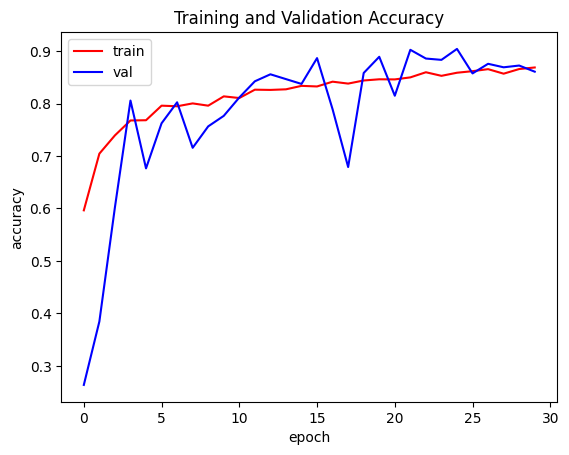

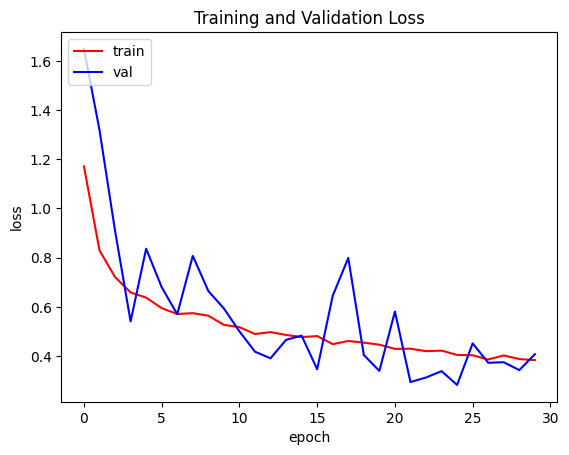

In [35]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validation Loss')
plt.show()

In [36]:
classif_report = classification_report(test_generator.classes,
                                       np.argmax(model.predict(test_generator), axis=-1),
                                       target_names=list(test_generator.class_indices.keys()))
print(classif_report)

1199/1199 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
              precision    recall  f1-score   support

       dress       0.74      0.92      0.82       184
       pants       0.86      0.94      0.90       322
       shirt       0.99      0.84      0.91       285
       shoes       0.79      0.94      0.86       250
      shorts       0.93      0.44      0.60       158

    accuracy                           0.85      1199
   macro avg       0.86      0.82      0.82      1199
weighted avg       0.87      0.85      0.84      1199



## Konversi Model

#### Save to SavedModel

In [37]:
save_path = 'saved_model'
model.export(save_path)

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138826099167248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095535568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095532496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826325900944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826325888080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095535760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095526160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095536912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095536336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095532880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138826095537872: Te

#### Convert to TFJS Model

In [38]:
!tensorflowjs_converter --input_format=tf_saved_model saved_model/ ./tfjs_model

2025-12-02 22:33:43.742794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764714823.763450   17533 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764714823.769721   17533 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764714823.785320   17533 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764714823.785353   17533 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764714823.785356   17533 computation_placer.cc:177] computation placer alr

#### Convert to TFJS-Lite

In [39]:
converter = tf.lite.TFLiteConverter.from_saved_model(save_path)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('tflite_model/model.tflite')
tflite_model_file.write_bytes(tflite_model)

411355636

## Inference (Optional)

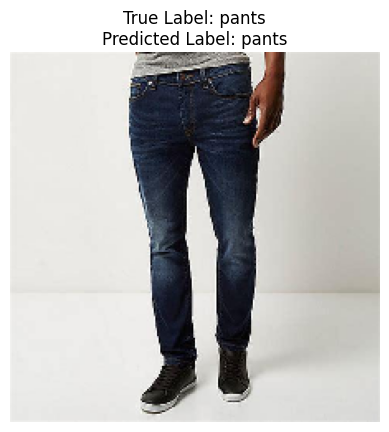

In [40]:
# Load the saved model using TFSMLayer for SavedModel format
loaded_model = TFSMLayer('saved_model', call_endpoint='serve')

# Get class names from the training generator
class_names = list(train_generator.class_indices.keys())

# Select a random image from the test set for inference
random_index = random.randint(0, len(X_test) - 1)
img_path = X_test[random_index]
true_label = y_test[random_index]

# Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Make prediction
predictions = loaded_model(img_array)
predicted_class_index = np.argmax(predictions[0])
predicted_label = class_names[predicted_class_index]

# Display the image and prediction
plt.imshow(img)
plt.title(f"True Label: {true_label}\nPredicted Label: {predicted_label}")
plt.axis('off')
plt.show()